In [1]:
pip install networkx python-louvain

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\lafp0\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import community.community_louvain as community_louvain # Librería python-louvain
import matplotlib.pyplot as plt
import zipfile

In [4]:
# ==========================================
# 1. CARGA DE DATOS (Top 100 Productos)
# ==========================================
print("Cargando y filtrando datos...")

try:
    with zipfile.ZipFile('../data/order_products__prior.csv.zip', 'r') as z:
        order_details = pd.read_csv(z.open('order_products__prior.csv'))
    
    with zipfile.ZipFile('../data/products.csv.zip', 'r') as z:
        products = pd.read_csv(z.open('products.csv'))

    # Filtramos Top 100 para que el grafo sea visualizable y procesable
    top_100 = order_details['product_id'].value_counts().head(100).index
    df_filtered = order_details[order_details['product_id'].isin(top_100)]
    
    # Pegamos los nombres reales
    df_merged = pd.merge(df_filtered, products[['product_id', 'product_name']], on='product_id')
    
    print(f"Datos listos: {len(df_merged):,} registros (Top 100 productos).")

except Exception as e:
    print(f"Error: {e}")

Cargando y filtrando datos...
Datos listos: 7,483,881 registros (Top 100 productos).


In [5]:
# ==========================================
# 2. CONSTRUCCIÓN DEL GRAFO (Técnica Big Data)
# ==========================================
print("Construyendo la red de co-compras...")

# Hacemos un "Self-Join": Cruzamos la tabla consigo misma usando 'order_id'
# Esto nos da pares: (Producto A, Producto B) que estaban en la misma orden.
df_pairs = pd.merge(df_merged, df_merged, on='order_id')

# Filtramos para no tener pares duplicados (A, B) y (B, A) o (A, A)
# Usamos product_id_x < product_id_y para asegurar orden único
df_pairs = df_pairs[df_pairs['product_id_x'] < df_pairs['product_id_y']]

# Contamos la fuerza de la conexión (Peso de la arista)
edge_weights = df_pairs.groupby(['product_name_x', 'product_name_y']).size().reset_index(name='weight')

print(f"Se encontraron {len(edge_weights)} conexiones únicas entre productos.")

# Inicializamos el grafo
G = nx.Graph()

# Añadimos las aristas con sus pesos
for _, row in edge_weights.iterrows():
    G.add_edge(row['product_name_x'], row['product_name_y'], weight=row['weight'])

print(f"Grafo creado: {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")

Construyendo la red de co-compras...
Se encontraron 4945 conexiones únicas entre productos.
Grafo creado: 100 nodos y 4945 aristas.


In [6]:
# ==========================================
# 3. ANÁLISIS DE CENTRALIDAD (PageRank - Unidad 5)
# ==========================================
# PageRank nos dice cuáles son los productos "Más Importantes" estructuralmente.
# Un producto tiene alto PR si se compra con otros productos importantes.

pagerank = nx.pagerank(G, weight='weight')
# Ordenamos
sorted_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)

print("\n--- Top 5 Productos 'Autoridad' (PageRank) ---")
for prod, score in sorted_pagerank[:5]:
    print(f"{prod}: {score:.4f}")


--- Top 5 Productos 'Autoridad' (PageRank) ---
Banana: 0.0432
Bag of Organic Bananas: 0.0373
Organic Strawberries: 0.0312
Organic Baby Spinach: 0.0305
Organic Hass Avocado: 0.0269


In [7]:
# ==========================================
# 4. DETECCIÓN DE COMUNIDADES (Louvain - Unidad 5)
# ==========================================
# Esto agrupará los productos en "Clusters" naturales (ej. Frutas, Lácteos, etc.)
# sin que nosotros le digamos la categoría.

partition = community_louvain.best_partition(G, weight='weight')

# Organizar resultados
communities = {}
for node, comm_id in partition.items():
    if comm_id not in communities:
        communities[comm_id] = []
    communities[comm_id].append(node)

print(f"\n--- Comunidades Detectadas: {len(communities)} ---")
for comm_id, items in communities.items():
    if len(items) > 5: # Solo mostrar comunidades relevantes
        print(f"\nComunidad {comm_id} ({len(items)} productos):")
        print(f"Ejemplos: {items[:5]}...") # Mostramos los primeros 5


--- Comunidades Detectadas: 4 ---

Comunidad 0 (39 productos):
Ejemplos: ['100% Raw Coconut Water', 'Apple Honeycrisp Organic', 'Bag of Organic Bananas', 'Hass Avocados', 'Large Alfresco Eggs']...

Comunidad 3 (36 productos):
Ejemplos: ['100% Whole Wheat Bread', '2% Reduced Fat Milk', 'Asparagus', 'Banana', 'Bartlett Pears']...

Comunidad 2 (21 productos):
Ejemplos: ['Carrots', 'Extra Virgin Olive Oil', 'Fresh Cauliflower', 'Grated Parmesan', 'Green Bell Pepper']...


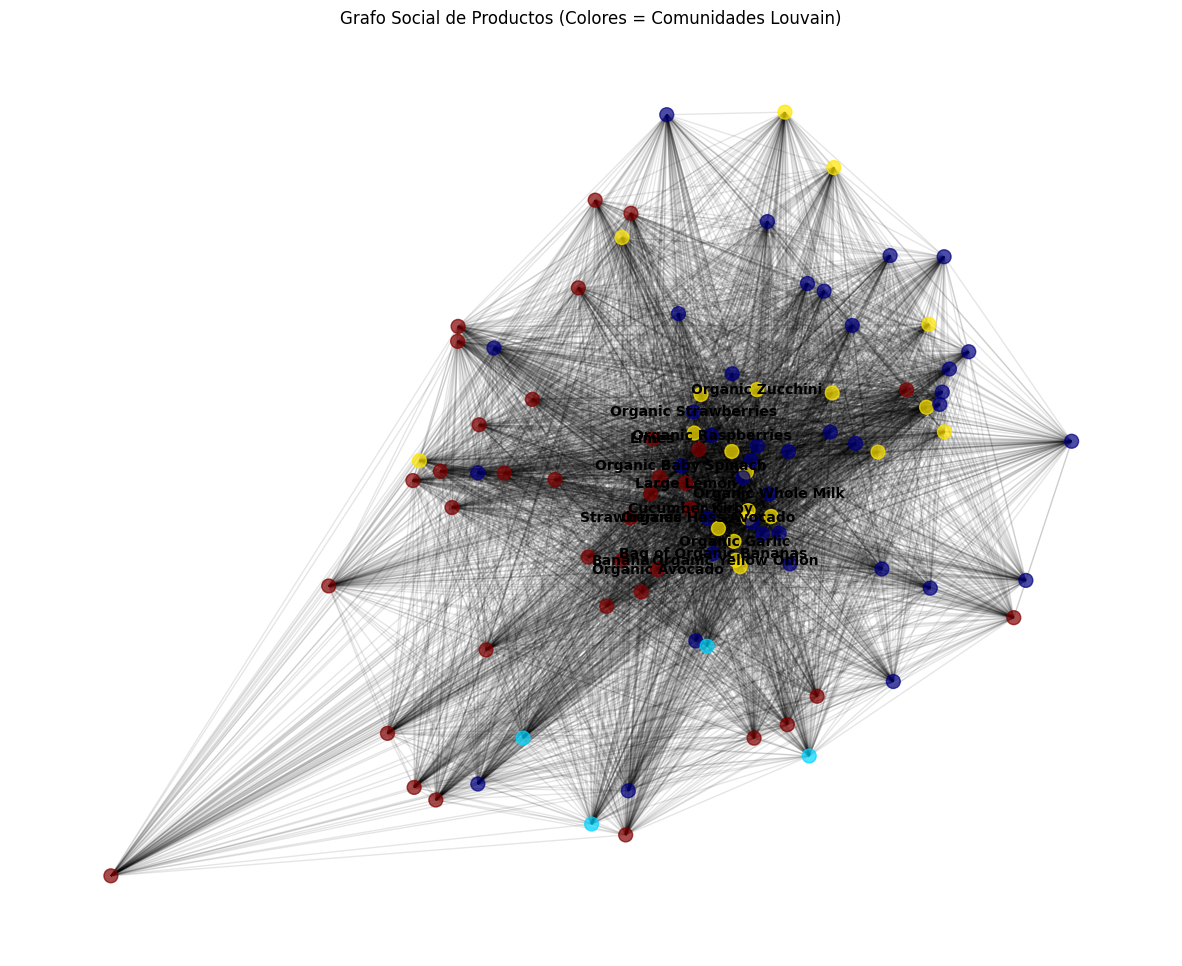

In [8]:
# ==========================================
# 5. VISUALIZACIÓN DEL GRAFO
# ==========================================
plt.figure(figsize=(15, 12))

# Posicionamiento de los nodos (Spring Layout usa fuerzas de atracción/repulsión)
pos = nx.spring_layout(G, k=0.15, seed=42)

# Colorear nodos según su comunidad
node_colors = [partition[node] for node in G.nodes()]

# Dibujar
nx.draw_networkx_nodes(G, pos, node_size=100, cmap=plt.cm.jet, node_color=node_colors, alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.1)

# Etiquetas (solo para los productos más importantes para no saturar)
top_nodes = [x[0] for x in sorted_pagerank[:15]] # Solo etiquetamos el Top 15
labels = {node: node for node in G.nodes() if node in top_nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold')

plt.title("Grafo Social de Productos (Colores = Comunidades Louvain)")
plt.axis('off')
plt.show()

# 4_Ranking_LTR

In [ ]:
# ==========================================
# 1. DEFINICIÓN DEL ESCENARIO (CARRITO DE USUARIO)
# ==========================================
# Imaginemos un usuario con perfil "Healthy" (Comunidad 0)
# Tiene estos productos en su carrito ahora mismo:
carrito_usuario = ['Bag of Organic Bananas', 'Organic Hass Avocado']

print(f"🛒 Carrito del Usuario: {carrito_usuario}")

In [ ]:
# ==========================================
# 2. GENERACIÓN DE CANDIDATOS (Recuperación)
# ==========================================
# Usamos las Reglas de Asociación (Unidad 2) para buscar candidatos.
# Buscamos reglas donde el antecedente esté en el carrito.

print("Buscando candidatos basados en reglas...")

# Filtramos las reglas generadas en el Bloque 2
# Convertimos frozensets a strings para buscar fácil
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: list(x)[0])
rules['consequents_str'] = rules['consequents'].apply(lambda x: list(x)[0])

candidates = rules[rules['antecedents_str'].isin(carrito_usuario)].copy()

# Nos quedamos con los productos sugeridos únicos
unique_candidates = candidates['consequents_str'].unique()

print(f"Candidates encontrados: {len(unique_candidates)}")
print(f"Ejemplos: {unique_candidates[:5]}")